# Extract Environmental Variable from GEE

## Import modules

In [1]:
import sys
sys.path.append('./src')

import pandas as pd
import ee
from src.auth import AuthenticationService
from src.variables.ndvi import extract_ndvi
from src.variables.canopy_height import extract_canopy_height
from src.variables.elevation import extract_elevation
from src.variables.landcover import extract_landcover
from src.variables.worldclim import extract_worldclim
from src.variables.biomass import extract_biomass
from src.variables.waterdist import extract_distance_to_water
from src.variables.nighttime_lights import extract_nighttime_lights
from src.variables.bii import extract_bii
from src.variables.satellite_embedding import extract_satellite_embedding
from src.aoi import create_aoi_from_coordinates
from src.utils import plot_map, plot_images
from src.sampling import clean_coordinates_dataframe, convert_points_to_buffered_features
from src.export import export_rasters_to_gdrive, export_csv, export_hexagrid_results

from src.hex_grid import generate_h3_hexagon_grid, extract_values_from_hexagons

## Setup

Define pipeline parameters:

In [2]:
# ============================================================
# 🌍 Google Earth Engine configuration
# ============================================================
GEE_PROJECT_ID = "wide-office-411000"   # GEE project used for API execution

## If using a service account instead of a login you can uncomment these:
# SERVICE_ACCOUNT = "service-account@google-cloud-project.iam.gserviceaccount.com" 
# SERVICE_ACCOUNT_KEY_FILE = "/abs/path/to/service-account-key.json"

# ============================================================
# 📥 Input data configuration
# ============================================================
LOCATIONS_CSV_PATH = "./input/locations.csv"  # Input file with sampling locations
LAT_COLUMN_NAME = "latitude"                      # Name of latitude column in CSV
LON_COLUMN_NAME = "longitude"                     # Name of longitude column in CSV


# ============================================================
# 🗺️ Spatial sampling configuration
# ============================================================
SAMPLING_POINT_BUFFER_METERS = 200   # Buffer radius around each point for NDVI/environment extraction
AOI_BUFFER_KM = 30                   # Additional buffer around all locations to define AOI
HEXAGRID_RESOLUTION = 5              # H3 resolution for hexagonal grid


# ============================================================
# 📤 Output paths
# ============================================================
OUTPUT_CSV_PATH = "output/site_env_vars.csv"                   # Output CSV for point-based variables
OUTPUT_HEXAGRID_PATH = "output/hexagrid"      # Hex-level results (CSV)


In [3]:
ok = AuthenticationService.authenticate(project_id=GEE_PROJECT_ID)
if not ok:
    raise SystemExit("Could not initialize EE")

✅ Google Earth Engine initialized


## Read Coordinates and define points and AOI

In [4]:
df = pd.read_csv(LOCATIONS_CSV_PATH)

df = clean_coordinates_dataframe(df,
                                 lat_col=LAT_COLUMN_NAME,
                                 lon_col=LON_COLUMN_NAME)

points_fc = convert_points_to_buffered_features(df,
                                                lat_col=LAT_COLUMN_NAME,
                                                lon_col=LON_COLUMN_NAME,
                                                buffer_meters=SAMPLING_POINT_BUFFER_METERS)

2025-12-17 13:42:31,927 - INFO - Successfully validated and cleaned 40 points.
2025-12-17 13:42:31,928 - INFO - Preparing sampling units for batch processing...


2025-12-17 13:42:31,967 - INFO - Creating map plot for 40 features...
2025-12-17 13:42:33,850 - INFO - Added basemap: satellite
2025-12-17 13:42:33,867 - INFO - Map plot created successfully


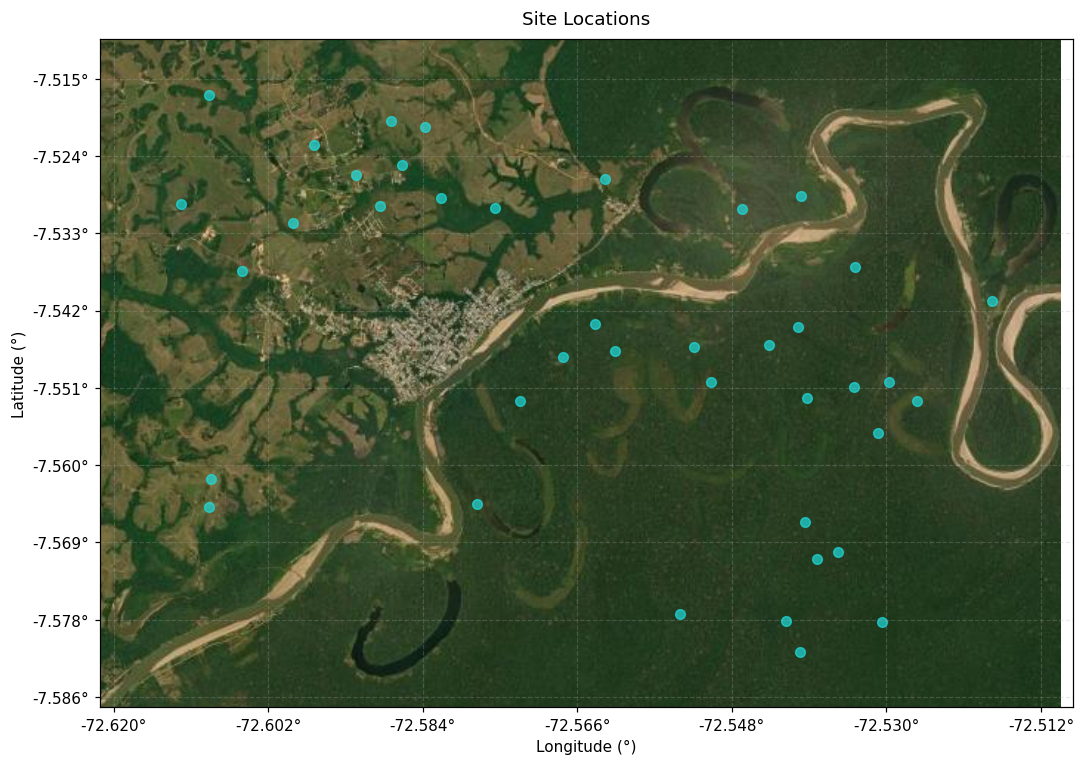

In [5]:
fig, ax = plot_map(df, 
                   basemap='satellite', 
                   alpha=0.7, 
                   color="#1FDBDB", 
                   buffer_pct=0.1,
                   title="Site Locations")  

In [6]:
aoi = create_aoi_from_coordinates(df,
                                  buffer_km=AOI_BUFFER_KM)

📍 AOI Bounds: Lat[-7.8512, -7.2471], Lon[-72.8843, -72.2454]
📊 Defined study area for 40 points with 30km margin.


## Extract variables for each site

In [7]:
# Process NDVI
df, image_ndvi = extract_ndvi(
    df=df,
    aoi=aoi,
    points_feature_collection=points_fc,
    start_date="2025-01-01",
    end_date="2025-12-31",
    scale=30,
    mask_water=True,
    cloud_cover_threshold=50
)
df

2025-12-17 13:42:34,439 - INFO - -----------------------------------------------
2025-12-17 13:42:34,439 - INFO - Starting --NDVI-- extraction...
2025-12-17 13:42:34,440 - INFO - Processing 40 points...
2025-12-17 13:42:34,440 - INFO - Date range: 2025-01-01 to 2025-12-31
2025-12-17 13:42:34,440 - INFO - Scale: 30m
2025-12-17 13:42:34,441 - INFO - Water masking: True
2025-12-17 13:42:34,441 - INFO - Creating Landsat composite for study area...
2025-12-17 13:42:34,768 - INFO - Found 17 Landsat-9 images for study area
2025-12-17 13:42:34,770 - INFO - Extracting NDVI statistics for each sampling unit...
2025-12-17 13:42:34,772 - INFO - Fetching results from Earth Engine...
2025-12-17 13:42:35,180 - INFO - Parsing results...
2025-12-17 13:42:35,181 - INFO - Successfully processed 40/40 points
2025-12-17 13:42:35,181 - INFO - NDVI range: 0.626 to 0.879
2025-12-17 13:42:35,182 - INFO - NDVI mean: 0.802 ± 0.073


,id,latitude,longitude,NDVI_mean,NDVI_std
0,1,-7.576890,-72.553969,0.859,0.009
1,2,-7.526730,-72.562637,0.749,0.093
2,3,-7.543823,-72.540252,0.861,0.011
3,4,-7.531851,-72.598930,0.685,0.056
4,5,-7.522827,-72.596477,0.664,0.086
5,6,-7.525192,-72.586297,0.733,0.104
6,7,-7.536930,-72.533569,0.870,0.007
7,8,-7.526303,-72.591688,0.661,0.109
8,9,-7.569753,-72.535630,0.855,0.008
9,10,-7.552388,-72.526359,0.823,0.040


In [8]:
df, image_canopy_height = extract_canopy_height(df,
                                                aoi=aoi,
                                                points_feature_collection=points_fc,
                                                scale=10)
df

2025-12-17 13:42:35,280 - INFO - -----------------------------------------------
2025-12-17 13:42:35,280 - INFO - Starting --Canopy Height-- extraction...
2025-12-17 13:42:35,280 - INFO - Scale: 10m
2025-12-17 13:42:35,280 - INFO - Loading ETH Global Canopy Height dataset...
2025-12-17 13:42:35,281 - INFO - Extracting canopy height statistics...
2025-12-17 13:42:35,282 - INFO - Fetching results from Earth Engine...
2025-12-17 13:42:35,649 - INFO - Merging canopy height values into dataframe...
2025-12-17 13:42:35,650 - INFO - Successfully processed 40/40 points with canopy data
2025-12-17 13:42:35,650 - INFO - Canopy height mean: 21.54 ± 10.33 m (range 5.11-34.81 m)


,id,latitude,longitude,NDVI_mean,NDVI_std,canopy_height_mean,canopy_height_std
0,1,-7.576890,-72.553969,0.859,0.009,33.828,1.168
1,2,-7.526730,-72.562637,0.749,0.093,13.670,5.924
2,3,-7.543823,-72.540252,0.861,0.011,33.548,1.066
3,4,-7.531851,-72.598930,0.685,0.056,8.736,3.636
4,5,-7.522827,-72.596477,0.664,0.086,10.422,3.274
5,6,-7.525192,-72.586297,0.733,0.104,11.831,3.192
6,7,-7.536930,-72.533569,0.870,0.007,33.209,4.101
7,8,-7.526303,-72.591688,0.661,0.109,8.034,2.673
8,9,-7.569753,-72.535630,0.855,0.008,34.162,1.092
9,10,-7.552388,-72.526359,0.823,0.040,20.747,9.050


In [9]:
df, image_biomass = extract_biomass(
    df,
    aoi=aoi,
    points_feature_collection=points_fc,
    scale=100,
    year=2022
)
df

2025-12-17 13:42:35,715 - INFO - -----------------------------------------------
2025-12-17 13:42:35,716 - INFO - Starting --Biomass (AGB)-- extraction...
2025-12-17 13:42:35,716 - INFO - Requested year: 2022
2025-12-17 13:42:35,716 - INFO - Scale: 100m
2025-12-17 13:42:35,716 - INFO - Loading ESA CCI AGB image...
2025-12-17 13:42:35,961 - INFO - Extracting biomass statistics...
2025-12-17 13:42:35,963 - INFO - Fetching biomass results from Earth Engine...
2025-12-17 13:42:36,644 - INFO - Merging biomass results into dataframe...
2025-12-17 13:42:36,646 - INFO - Successfully processed 39/40 points with biomass data
2025-12-17 13:42:36,647 - INFO - Biomass mean: 187.41 ± 106.27 t/ha (range 4.83-307.23 t/ha)


,id,latitude,longitude,NDVI_mean,NDVI_std,canopy_height_mean,canopy_height_std,biomass_mean,biomass_std
0,1,-7.576890,-72.553969,0.859,0.009,33.828,1.168,277.569,34.156
1,2,-7.526730,-72.562637,0.749,0.093,13.670,5.924,39.620,63.172
2,3,-7.543823,-72.540252,0.861,0.011,33.548,1.066,270.503,31.296
3,4,-7.531851,-72.598930,0.685,0.056,8.736,3.636,NaN,NaN
4,5,-7.522827,-72.596477,0.664,0.086,10.422,3.274,41.957,17.392
5,6,-7.525192,-72.586297,0.733,0.104,11.831,3.192,68.617,79.438
6,7,-7.536930,-72.533569,0.870,0.007,33.209,4.101,254.411,40.855
7,8,-7.526303,-72.591688,0.661,0.109,8.034,2.673,78.000,0.000
8,9,-7.569753,-72.535630,0.855,0.008,34.162,1.092,259.873,35.220
9,10,-7.552388,-72.526359,0.823,0.040,20.747,9.050,273.567,64.743


In [10]:
df, image_landcover = extract_landcover(
    df,
    aoi=aoi,
    points_feature_collection=points_fc,
    scale=10
)
df

2025-12-17 13:42:36,714 - INFO - -----------------------------------------------
2025-12-17 13:42:36,715 - INFO - Starting --ESA WorldCover-- extraction...
2025-12-17 13:42:36,715 - INFO - Date range: 2021
2025-12-17 13:42:36,716 - INFO - Scale: 10m
2025-12-17 13:42:36,716 - INFO - Loading ESA WorldCover composite for study area...
2025-12-17 13:42:36,716 - INFO - Extracting dominant landcover and class proportions...
2025-12-17 13:42:36,726 - INFO - Fetching landcover statistics from Earth Engine...
2025-12-17 13:42:37,306 - INFO - Merging landcover results into dataframe...
2025-12-17 13:42:37,310 - INFO - Successfully processed 40/40 points with landcover data
2025-12-17 13:42:37,311 - INFO - Dominant landcover distribution:
2025-12-17 13:42:37,311 - INFO -   Tree_cover: 30 points (75.0%)
2025-12-17 13:42:37,312 - INFO -   Grassland: 10 points (25.0%)


,id,latitude,longitude,NDVI_mean,NDVI_std,canopy_height_mean,canopy_height_std,biomass_mean,biomass_std,landcover_prop_Tree_cover,...,landcover_prop_Grassland,landcover_prop_Cropland,landcover_prop_Built_up,landcover_prop_Bare_sparse_vegetation,landcover_prop_Snow_and_ice,landcover_prop_Permanent_water_bodies,landcover_prop_Herbaceous_wetland,landcover_prop_Mangroves,landcover_prop_Moss_and_lichen,landcover_dominant_label
0,1,-7.576890,-72.553969,0.859,0.009,33.828,1.168,277.569,34.156,1.000,...,0.000,0.0,0.0,0.000,0.0,0.000,0.0,0.0,0.0,Tree_cover
1,2,-7.526730,-72.562637,0.749,0.093,13.670,5.924,39.620,63.172,0.500,...,0.500,0.0,0.0,0.000,0.0,0.000,0.0,0.0,0.0,Grassland
2,3,-7.543823,-72.540252,0.861,0.011,33.548,1.066,270.503,31.296,1.000,...,0.000,0.0,0.0,0.000,0.0,0.000,0.0,0.0,0.0,Tree_cover
3,4,-7.531851,-72.598930,0.685,0.056,8.736,3.636,NaN,NaN,0.170,...,0.830,0.0,0.0,0.000,0.0,0.000,0.0,0.0,0.0,Grassland
4,5,-7.522827,-72.596477,0.664,0.086,10.422,3.274,41.957,17.392,0.247,...,0.751,0.0,0.0,0.002,0.0,0.000,0.0,0.0,0.0,Grassland
5,6,-7.525192,-72.586297,0.733,0.104,11.831,3.192,68.617,79.438,0.501,...,0.499,0.0,0.0,0.000,0.0,0.000,0.0,0.0,0.0,Tree_cover
6,7,-7.536930,-72.533569,0.870,0.007,33.209,4.101,254.411,40.855,1.000,...,0.000,0.0,0.0,0.000,0.0,0.000,0.0,0.0,0.0,Tree_cover
7,8,-7.526303,-72.591688,0.661,0.109,8.034,2.673,78.000,0.000,0.090,...,0.896,0.0,0.0,0.004,0.0,0.010,0.0,0.0,0.0,Grassland
8,9,-7.569753,-72.535630,0.855,0.008,34.162,1.092,259.873,35.220,1.000,...,0.000,0.0,0.0,0.000,0.0,0.000,0.0,0.0,0.0,Tree_cover
9,10,-7.552388,-72.526359,0.823,0.040,20.747,9.050,273.567,64.743,0.927,...,0.073,0.0,0.0,0.000,0.0,0.000,0.0,0.0,0.0,Tree_cover


In [11]:
df, image_elevation = extract_elevation(df=df,
                                        aoi=aoi,
                                        points_feature_collection=points_fc,
                                        scale=30)
df

2025-12-17 13:42:37,390 - INFO - -----------------------------------------------
2025-12-17 13:42:37,390 - INFO - Starting --Elevation & Slope-- extraction...
2025-12-17 13:42:37,391 - INFO - Scale: 30m
2025-12-17 13:42:37,391 - INFO - Loading SRTM elevation dataset...
2025-12-17 13:42:37,392 - INFO - Extracting elevation and slope statistics...
2025-12-17 13:42:37,394 - INFO - Fetching results from Earth Engine...
2025-12-17 13:42:37,822 - INFO - Merging elevation and slope values into dataframe...
2025-12-17 13:42:37,824 - INFO - Successfully processed 40/40 points with elevation data
2025-12-17 13:42:37,824 - INFO - Successfully processed 40/40 points with slope data
2025-12-17 13:42:37,825 - INFO - Elevation mean: 186.84 ± 9.69 m (range 173.36-210.37 m)
2025-12-17 13:42:37,825 - INFO - Slope mean: 9.74 ± 3.97 deg (range 2.92-21.84 deg)


,id,latitude,longitude,NDVI_mean,NDVI_std,canopy_height_mean,canopy_height_std,biomass_mean,biomass_std,landcover_prop_Tree_cover,...,landcover_prop_Snow_and_ice,landcover_prop_Permanent_water_bodies,landcover_prop_Herbaceous_wetland,landcover_prop_Mangroves,landcover_prop_Moss_and_lichen,landcover_dominant_label,elevation_mean,elevation_std,slope_percent_mean,slope_percent_std
0,1,-7.576890,-72.553969,0.859,0.009,33.828,1.168,277.569,34.156,1.000,...,0.0,0.000,0.0,0.0,0.0,Tree_cover,189.301,2.498,6.884,3.647
1,2,-7.526730,-72.562637,0.749,0.093,13.670,5.924,39.620,63.172,0.500,...,0.0,0.000,0.0,0.0,0.0,Grassland,173.357,4.474,9.684,5.977
2,3,-7.543823,-72.540252,0.861,0.011,33.548,1.066,270.503,31.296,1.000,...,0.0,0.000,0.0,0.0,0.0,Tree_cover,188.718,4.101,10.519,5.990
3,4,-7.531851,-72.598930,0.685,0.056,8.736,3.636,NaN,NaN,0.170,...,0.0,0.000,0.0,0.0,0.0,Grassland,193.630,8.483,9.519,5.852
4,5,-7.522827,-72.596477,0.664,0.086,10.422,3.274,41.957,17.392,0.247,...,0.0,0.000,0.0,0.0,0.0,Grassland,206.364,9.500,14.946,7.956
5,6,-7.525192,-72.586297,0.733,0.104,11.831,3.192,68.617,79.438,0.501,...,0.0,0.000,0.0,0.0,0.0,Tree_cover,178.492,3.730,6.979,4.619
6,7,-7.536930,-72.533569,0.870,0.007,33.209,4.101,254.411,40.855,1.000,...,0.0,0.000,0.0,0.0,0.0,Tree_cover,189.671,4.045,9.910,5.154
7,8,-7.526303,-72.591688,0.661,0.109,8.034,2.673,78.000,0.000,0.090,...,0.0,0.010,0.0,0.0,0.0,Grassland,183.486,3.066,5.151,3.591
8,9,-7.569753,-72.535630,0.855,0.008,34.162,1.092,259.873,35.220,1.000,...,0.0,0.000,0.0,0.0,0.0,Tree_cover,187.816,2.354,6.385,3.503
9,10,-7.552388,-72.526359,0.823,0.040,20.747,9.050,273.567,64.743,0.927,...,0.0,0.000,0.0,0.0,0.0,Tree_cover,179.171,9.985,16.365,12.351


In [12]:
df, image_waterdist = extract_distance_to_water(
    df,
    aoi=aoi,
    points_feature_collection=points_fc,
    scale=30,
    max_search_distance=20_000,
)
df

2025-12-17 13:42:37,906 - INFO - -----------------------------------------------
2025-12-17 13:42:37,907 - INFO - Starting --Distance to Water-- extraction...
2025-12-17 13:42:37,907 - INFO - Sampling scale: 30m
2025-12-17 13:42:37,907 - INFO - Max search distance: 20000m, pixels beyond this will be set to 20001m
2025-12-17 13:42:37,907 - INFO - Loading water datasets at native resolution...
2025-12-17 13:42:37,908 - INFO - Combining water layers...
2025-12-17 13:42:37,908 - INFO - Building distance surface using FDT...
2025-12-17 13:42:37,908 - INFO - Sampling distance values at sampling point centroids...
2025-12-17 13:42:37,910 - INFO - Fetching distance results...
2025-12-17 13:42:38,294 - INFO - Merging distances into dataframe...
2025-12-17 13:42:38,295 - INFO - Successfully processed 40/40 points with distance-to-water data
2025-12-17 13:42:38,295 - INFO - Distance to water: mean 1259.8 m (min 67.1 m, max 3121.9 m)


,id,latitude,longitude,NDVI_mean,NDVI_std,canopy_height_mean,canopy_height_std,biomass_mean,biomass_std,landcover_prop_Tree_cover,...,landcover_prop_Permanent_water_bodies,landcover_prop_Herbaceous_wetland,landcover_prop_Mangroves,landcover_prop_Moss_and_lichen,landcover_dominant_label,elevation_mean,elevation_std,slope_percent_mean,slope_percent_std,distance_to_water_m
0,1,-7.576890,-72.553969,0.859,0.009,33.828,1.168,277.569,34.156,1.000,...,0.000,0.0,0.0,0.0,Tree_cover,189.301,2.498,6.884,3.647,1493.084
1,2,-7.526730,-72.562637,0.749,0.093,13.670,5.924,39.620,63.172,0.500,...,0.000,0.0,0.0,0.0,Grassland,173.357,4.474,9.684,5.977,450.000
2,3,-7.543823,-72.540252,0.861,0.011,33.548,1.066,270.503,31.296,1.000,...,0.000,0.0,0.0,0.0,Tree_cover,188.718,4.101,10.519,5.990,660.000
3,4,-7.531851,-72.598930,0.685,0.056,8.736,3.636,NaN,NaN,0.170,...,0.000,0.0,0.0,0.0,Grassland,193.630,8.483,9.519,5.852,1302.498
4,5,-7.522827,-72.596477,0.664,0.086,10.422,3.274,41.957,17.392,0.247,...,0.000,0.0,0.0,0.0,Grassland,206.364,9.500,14.946,7.956,2250.800
5,6,-7.525192,-72.586297,0.733,0.104,11.831,3.192,68.617,79.438,0.501,...,0.000,0.0,0.0,0.0,Tree_cover,178.492,3.730,6.979,4.619,2253.996
6,7,-7.536930,-72.533569,0.870,0.007,33.209,4.101,254.411,40.855,1.000,...,0.000,0.0,0.0,0.0,Tree_cover,189.671,4.045,9.910,5.154,216.333
7,8,-7.526303,-72.591688,0.661,0.109,8.034,2.673,78.000,0.000,0.090,...,0.010,0.0,0.0,0.0,Grassland,183.486,3.066,5.151,3.591,1906.830
8,9,-7.569753,-72.535630,0.855,0.008,34.162,1.092,259.873,35.220,1.000,...,0.000,0.0,0.0,0.0,Tree_cover,187.816,2.354,6.385,3.503,1963.110
9,10,-7.552388,-72.526359,0.823,0.040,20.747,9.050,273.567,64.743,0.927,...,0.000,0.0,0.0,0.0,Tree_cover,179.171,9.985,16.365,12.351,390.000


In [13]:
df, image_bii = extract_bii(
    df=df,
    aoi=aoi,
    points_feature_collection=points_fc,
    year=2020,
    scale=100
)

2025-12-17 13:42:38,369 - INFO - -----------------------------------------------
2025-12-17 13:42:38,369 - INFO - Starting --Biodiversity Intactness Index-- extraction...
2025-12-17 13:42:38,369 - INFO - Requested year: 2020
2025-12-17 13:42:38,369 - INFO - Scale: 100m
2025-12-17 13:42:38,370 - INFO - Loading BII image...
2025-12-17 13:42:38,722 - INFO - Extracting BII statistics...
2025-12-17 13:42:38,723 - INFO - Fetching BII results from Earth Engine...
2025-12-17 13:42:39,251 - INFO - Merging BII results into dataframe...
2025-12-17 13:42:39,253 - INFO - Successfully processed 40/40 points with BII data
2025-12-17 13:42:39,253 - INFO - BII mean: 0.83 ± 0.11 (range 0.61-0.94)


In [14]:
df, image_nightlights = extract_nighttime_lights(
    df,
    aoi=aoi,
    points_feature_collection=points_fc,
    scale=464,
    year=2022
)
df

2025-12-17 13:42:39,281 - INFO - -----------------------------------------------
2025-12-17 13:42:39,282 - INFO - Starting --Nighttime Lights-- extraction...
2025-12-17 13:42:39,282 - INFO - Requested year: 2022
2025-12-17 13:42:39,282 - INFO - Scale: 464m
2025-12-17 13:42:39,283 - INFO - Loading VIIRS annual nighttime lights image...
2025-12-17 13:42:39,562 - INFO - Extracting nighttime lights statistics...
2025-12-17 13:42:39,564 - INFO - Fetching nighttime lights results from Earth Engine...
2025-12-17 13:42:39,998 - INFO - Merging nighttime lights results into dataframe...
2025-12-17 13:42:39,999 - INFO - Successfully processed 40/40 points with nighttime lights data
2025-12-17 13:42:39,999 - INFO - Nighttime lights mean: 0.67 ± 0.48 (range 0.28-2.29)


,id,latitude,longitude,NDVI_mean,NDVI_std,canopy_height_mean,canopy_height_std,biomass_mean,biomass_std,landcover_prop_Tree_cover,...,landcover_dominant_label,elevation_mean,elevation_std,slope_percent_mean,slope_percent_std,distance_to_water_m,biointactness_mean,biointactness_std,nighttime_lights_mean,nighttime_lights_std
0,1,-7.576890,-72.553969,0.859,0.009,33.828,1.168,277.569,34.156,1.000,...,Tree_cover,189.301,2.498,6.884,3.647,1493.084,0.935,0.000,0.299,0.011
1,2,-7.526730,-72.562637,0.749,0.093,13.670,5.924,39.620,63.172,0.500,...,Grassland,173.357,4.474,9.684,5.977,450.000,0.762,0.049,1.915,0.278
2,3,-7.543823,-72.540252,0.861,0.011,33.548,1.066,270.503,31.296,1.000,...,Tree_cover,188.718,4.101,10.519,5.990,660.000,0.912,0.000,0.460,0.043
3,4,-7.531851,-72.598930,0.685,0.056,8.736,3.636,NaN,NaN,0.170,...,Grassland,193.630,8.483,9.519,5.852,1302.498,0.641,0.058,0.698,0.215
4,5,-7.522827,-72.596477,0.664,0.086,10.422,3.274,41.957,17.392,0.247,...,Grassland,206.364,9.500,14.946,7.956,2250.800,0.638,0.072,0.869,0.244
5,6,-7.525192,-72.586297,0.733,0.104,11.831,3.192,68.617,79.438,0.501,...,Tree_cover,178.492,3.730,6.979,4.619,2253.996,0.838,0.033,0.731,0.115
6,7,-7.536930,-72.533569,0.870,0.007,33.209,4.101,254.411,40.855,1.000,...,Tree_cover,189.671,4.045,9.910,5.154,216.333,0.894,0.019,0.361,0.015
7,8,-7.526303,-72.591688,0.661,0.109,8.034,2.673,78.000,0.000,0.090,...,Grassland,183.486,3.066,5.151,3.591,1906.830,0.819,0.011,1.209,0.046
8,9,-7.569753,-72.535630,0.855,0.008,34.162,1.092,259.873,35.220,1.000,...,Tree_cover,187.816,2.354,6.385,3.503,1963.110,0.939,0.000,0.304,0.003
9,10,-7.552388,-72.526359,0.823,0.040,20.747,9.050,273.567,64.743,0.927,...,Tree_cover,179.171,9.985,16.365,12.351,390.000,0.892,0.027,0.422,0.011


In [15]:
# Do not save embeddings images for now
df, _ = extract_satellite_embedding(
    df=df,
    aoi=aoi,
    points_feature_collection=points_fc,
    year=2024,
    scale=10
)

2025-12-17 13:42:40,070 - INFO - -----------------------------------------------
2025-12-17 13:42:40,071 - INFO - Starting --Satellite Embedding V1-- extraction...
2025-12-17 13:42:40,071 - INFO - Requested year: 2024
2025-12-17 13:42:40,071 - INFO - Scale: 10m
2025-12-17 13:42:40,071 - INFO - Loading Satellite Embedding image...
2025-12-17 13:42:40,420 - INFO - Extracting embedding vectors...
2025-12-17 13:42:40,423 - INFO - Fetching embedding results from Earth Engine...
2025-12-17 13:42:40,837 - INFO - Merging embeddings into dataframe...
2025-12-17 13:42:40,838 - INFO - Successfully processed 40/40 points with satellite embeddings


In [16]:
df, image_worldclim = extract_worldclim(df,
                                        aoi=aoi,
                                        points_feature_collection=points_fc,
                                        variables=['bio01', 'bio02'], # comment/uncomment to select all/specific variables
                                        )
df

2025-12-17 13:42:40,858 - INFO - -----------------------------------------------
2025-12-17 13:42:40,858 - INFO - Starting --WorldClim-- extraction...
2025-12-17 13:42:40,859 - INFO - Variables: bio01, bio02
2025-12-17 13:42:40,859 - INFO - Scale: 1000m
2025-12-17 13:42:40,859 - INFO - Loading WorldClim image for study area...
2025-12-17 13:42:40,859 - INFO - Extracting bioclimatic statistics...
2025-12-17 13:42:40,861 - INFO - Fetching results from Earth Engine...
2025-12-17 13:42:41,126 - INFO - Merging WorldClim results into dataframe...
2025-12-17 13:42:41,127 - INFO - Successfully processed 40/40 points with WorldClim data
2025-12-17 13:42:41,128 - INFO - Annual Mean Temperature (bio01): 25.3°C to 25.5°C (mean 25.4°C)


,id,latitude,longitude,NDVI_mean,NDVI_std,canopy_height_mean,canopy_height_std,biomass_mean,biomass_std,landcover_prop_Tree_cover,...,distance_to_water_m,biointactness_mean,biointactness_std,nighttime_lights_mean,nighttime_lights_std,satellite_embeddings_v1,bio01_mean,bio01_stdDev,bio02_mean,bio02_stdDev
0,1,-7.576890,-72.553969,0.859,0.009,33.828,1.168,277.569,34.156,1.000,...,1493.084,0.935,0.000,0.299,0.011,"[-0.06361315254455209, -0.017169264871389072, ...",25.303,0.050,9.800,0.00
1,2,-7.526730,-72.562637,0.749,0.093,13.670,5.924,39.620,63.172,0.500,...,450.000,0.762,0.049,1.915,0.278,"[-0.09821686737505564, 0.08936676319202456, -0...",25.412,0.050,9.800,0.00
2,3,-7.543823,-72.540252,0.861,0.011,33.548,1.066,270.503,31.296,1.000,...,660.000,0.912,0.000,0.460,0.043,"[-0.070164432596416, -0.009846828075752689, -0...",25.400,0.000,9.800,0.00
3,4,-7.531851,-72.598930,0.685,0.056,8.736,3.636,NaN,NaN,0.170,...,1302.498,0.641,0.058,0.698,0.215,"[-0.05960651584054134, 0.12561516781004328, -0...",25.303,0.050,9.800,0.00
4,5,-7.522827,-72.596477,0.664,0.086,10.422,3.274,41.957,17.392,0.247,...,2250.800,0.638,0.072,0.869,0.244,"[-0.060425105262196736, 0.1741032643366082, -0...",25.381,0.050,9.800,0.00
5,6,-7.525192,-72.586297,0.733,0.104,11.831,3.192,68.617,79.438,0.501,...,2253.996,0.838,0.033,0.731,0.115,"[-0.05798423143102881, 0.1592042347050482, -0....",25.400,0.000,9.800,0.00
6,7,-7.536930,-72.533569,0.870,0.007,33.209,4.101,254.411,40.855,1.000,...,216.333,0.894,0.019,0.361,0.015,"[-0.08463187930036309, -0.0140636317038609, -0...",25.400,0.000,9.800,0.00
7,8,-7.526303,-72.591688,0.661,0.109,8.034,2.673,78.000,0.000,0.090,...,1906.830,0.819,0.011,1.209,0.046,"[-0.08176845075538262, 0.15414934397858926, -0...",25.400,0.000,9.800,0.00
8,9,-7.569753,-72.535630,0.855,0.008,34.162,1.092,259.873,35.220,1.000,...,1963.110,0.939,0.000,0.304,0.003,"[-0.05698623984308917, -0.01882424054110386, -...",25.400,0.000,9.800,0.00
9,10,-7.552388,-72.526359,0.823,0.040,20.747,9.050,273.567,64.743,0.927,...,390.000,0.892,0.027,0.422,0.011,"[-0.03933555853329628, 0.09530181160993875, -0...",25.400,0.000,9.823,0.05


## Export results CSV

In [ ]:
export_csv(df, OUTPUT_CSV_PATH)``


Result saved to output/site_env_vars.csv


## Select variables for AOI operations (Raster and HexGrid exports)

In [18]:
# Select variables that you want to include in the image stack for the rasters and hexgrid exports
image_stack = ee.Image.cat([
    image_ndvi,
    image_canopy_height,
    image_biomass,
    image_landcover,
    image_elevation,
    image_waterdist,
    image_bii,
    image_nightlights,
    image_worldclim,
])

Plot any raster before any exporting if you want to double check them

In [20]:
map = plot_images(image_stack,
                  aoi=aoi,
                  points_fc=points_fc,
                  zoom=10,
                  scale=30,
                  filter_bands=['canopy_height'],
                  )
map

2025-12-17 13:42:51,757 - INFO - Available bands in image: ndvi, canopy_height, biomass, land_cover, elevation, slope_percent, water_mask, distance_to_water_m, biointactness, nighttime_lights, bio01, bio02
2025-12-17 13:42:51,758 - INFO - Plotting 1 bands: canopy_height
2025-12-17 13:42:52,745 - INFO - Band 'canopy_height': min=0.0000, max=41.0000
2025-12-17 13:42:53,705 - INFO - Map created successfully


Map(center=[-7.54913703614208, -72.56485996495522], controls=(WidgetControl(options=['position', 'transparent_…

## Export raw rasters

In [21]:
# Uncomment to export raw rasters
export_rasters_to_gdrive(
   image=image_stack,
   region=aoi,
   scale=100,
   crs="EPSG:4326",
   file_format="GeoTIFF",
   #    file_name_prefix="2025"
)

✅ Started export for band: ndvi -> ndvi
✅ Started export for band: canopy_height -> canopy_height
✅ Started export for band: biomass -> biomass
✅ Started export for band: land_cover -> land_cover
✅ Started export for band: elevation -> elevation
✅ Started export for band: slope_percent -> slope_percent
✅ Started export for band: water_mask -> water_mask
✅ Started export for band: distance_to_water_m -> distance_to_water_m
✅ Started export for band: biointactness -> biointactness
✅ Started export for band: nighttime_lights -> nighttime_lights
✅ Started export for band: bio01 -> bio01
✅ Started export for band: bio02 -> bio02
🔗 Monitor progress at: https://code.earthengine.google.com/tasks


## Creating hexagon and extraction values

Select images or bands to extract values for hexagons

In [ ]:

image_stack = ee.Image.cat([
    image_ndvi,
    image_canopy_height,
    image_biomass,
    image_landcover,
    image_elevation,
    image_waterdist.select('water_distance_m'), # drop water mask
    image_bii,
    image_nightlights,
    image_worldclim,
])

In [22]:
hex_gdf = generate_h3_hexagon_grid(aoi=aoi,
                                   h3_resolution=HEXAGRID_RESOLUTION,
                                   crs="EPSG:4326")
hex_gdf

Generated 16 hexagons


,geometry,h3_id,hexagon_area_km2,hexagon_area_m2
0,"POLYGON ((-72.77268 -7.22881, -72.82653 -7.306...",858f6bb7fffffff,287.771073,2.877711e+08
1,"POLYGON ((-72.51646 -7.58392, -72.57021 -7.662...",858b492bfffffff,287.263727,2.872637e+08
2,"POLYGON ((-72.38173 -7.67895, -72.43541 -7.757...",858b4977fffffff,286.922738,2.869227e+08
3,"POLYGON ((-72.81282 -7.72309, -72.86677 -7.801...",858b4937fffffff,288.214872,2.882149e+08
4,"POLYGON ((-72.9209 -7.29814, -72.97485 -7.3762...",858f6ba3fffffff,288.247390,2.882474e+08
5,"POLYGON ((-72.66453 -7.65349, -72.71838 -7.731...",858b4923fffffff,287.742248,2.877422e+08
6,"POLYGON ((-72.63794 -7.32411, -72.69172 -7.402...",858f696bfffffff,287.447063,2.874471e+08
7,"POLYGON ((-72.35547 -7.34985, -72.40909 -7.427...",858f6967fffffff,286.628953,2.866290e+08
8,"POLYGON ((-72.65123 -7.48877, -72.70505 -7.566...",858b492ffffffff,287.598192,2.875982e+08
9,"POLYGON ((-72.34237 -7.18539, -72.39595 -7.263...",858f6977fffffff,286.471519,2.864715e+08


In [23]:
hexagons_with_data = extract_values_from_hexagons(
    hex_gdf=hex_gdf,
    image_stack=image_stack,
    batch_size=100, 
    tileScale=4, # increase up to 16 if having memory issues
)

Using image_stack with BAND_CONFIG/defaults for 12 bands...
  ✓ ndvi: 30m, mean
  ✓ canopy_height: 10m, mean
  ✓ biomass: 100m, mean
  ✓ land_cover: 10m, mode
  ✓ elevation: 30m, mean
  ✓ slope_percent: 30m, mean
  ✓ water_mask: 30m, mode
  ✓ distance_to_water_m: 30m, mean
  ✓ biointactness: 100m, mean
  ✓ nighttime_lights: 464m, mean
  ✓ bio01: 1000m, mean
  ✓ bio02: 1000m, mean

Total hexagons to process: 16
Scale/Reducer groups:
  - 30m/mean: 4 band(s) ['ndvi', 'elevation', 'slope_percent', 'distance_to_water_m']
  - 10m/mean: 1 band(s) ['canopy_height']
  - 100m/mean: 2 band(s) ['biomass', 'biointactness']
  - 10m/mode: 1 band(s) ['land_cover']
  - 30m/mode: 1 band(s) ['water_mask']
  - 464m/mean: 1 band(s) ['nighttime_lights']
  - 1000m/mean: 2 band(s) ['bio01', 'bio02']


ndvi:   0%|          | 0/16 [00:00<?, ?hex/s]

canopy_height:   0%|          | 0/16 [00:00<?, ?hex/s]

biomass:   0%|          | 0/16 [00:00<?, ?hex/s]

land_cover:   0%|          | 0/16 [00:00<?, ?hex/s]

...

nighttime_lights:   0%|          | 0/16 [00:00<?, ?hex/s]

bio01:   0%|          | 0/16 [00:00<?, ?hex/s]

bio02:   0%|          | 0/16 [00:00<?, ?hex/s]

2025-12-17 13:44:09,237 - INFO - Created 16 records



✓ ALL DONE!

Final check:
  ndvi (mean): 16/16 non-null values
  canopy_height (mean): 16/16 non-null values
  biomass (mean): 16/16 non-null values
  land_cover (mode): 16/16 non-null values
  elevation (mean): 16/16 non-null values
  slope_percent (mean): 16/16 non-null values
  water_mask (mode): 13/16 non-null values
  distance_to_water_m (mean): 16/16 non-null values
  biointactness (mean): 16/16 non-null values
  nighttime_lights (mean): 16/16 non-null values
  bio01 (mean): 16/16 non-null values
  bio02 (mean): 16/16 non-null values


In [24]:
hexagons_with_data

,geometry,h3_id,hexagon_area_km2,hexagon_area_m2,ndvi,canopy_height,biomass,land_cover,elevation,slope_percent,water_mask,distance_to_water_m,biointactness,nighttime_lights,bio01,bio02
0,"POLYGON ((-72.77268 -7.22881, -72.82653 -7.306...",858f6bb7fffffff,287.771,2.877711e+08,0.829,28.355,275.991,Tree_cover,203.393,7.994,NaN,10554.724,0.915,0.253,25.410,9.928
1,"POLYGON ((-72.51646 -7.58392, -72.57021 -7.662...",858b492bfffffff,287.264,2.872637e+08,0.816,25.766,244.387,Tree_cover,189.020,6.669,1.0,3287.955,0.877,0.313,25.403,9.894
2,"POLYGON ((-72.38173 -7.67895, -72.43541 -7.757...",858b4977fffffff,286.923,2.869227e+08,0.804,23.600,236.736,Tree_cover,217.818,11.188,1.0,5697.026,0.852,0.326,25.354,9.995
3,"POLYGON ((-72.81282 -7.72309, -72.86677 -7.801...",858b4937fffffff,288.215,2.882149e+08,0.805,23.322,212.395,Tree_cover,229.504,13.522,1.0,5907.193,0.854,0.267,25.272,10.011
4,"POLYGON ((-72.9209 -7.29814, -72.97485 -7.3762...",858f6ba3fffffff,288.247,2.882474e+08,0.831,24.265,247.425,Tree_cover,208.780,6.010,NaN,13480.301,0.928,0.233,25.414,9.994
5,"POLYGON ((-72.66453 -7.65349, -72.71838 -7.731...",858b4923fffffff,287.742,2.877422e+08,0.808,24.164,217.752,Tree_cover,188.673,7.986,1.0,2067.401,0.838,0.625,25.374,9.881
6,"POLYGON ((-72.63794 -7.32411, -72.69172 -7.402...",858f696bfffffff,287.447,2.874471e+08,0.807,24.821,246.270,Tree_cover,205.135,9.853,NaN,7932.526,0.888,0.250,25.324,9.890
7,"POLYGON ((-72.35547 -7.34985, -72.40909 -7.427...",858f6967fffffff,286.629,2.866290e+08,0.864,31.011,305.809,Tree_cover,181.615,6.711,1.0,2359.028,0.976,0.221,25.490,9.901
8,"POLYGON ((-72.65123 -7.48877, -72.70505 -7.566...",858b492ffffffff,287.598,2.875982e+08,0.786,21.066,210.018,Tree_cover,190.802,9.967,1.0,1588.984,0.795,2.007,25.338,9.812
9,"POLYGON ((-72.34237 -7.18539, -72.39595 -7.263...",858f6977fffffff,286.472,2.864715e+08,0.856,30.511,307.656,Tree_cover,174.037,7.679,1.0,1599.307,0.963,0.216,25.549,9.900


<Axes: >

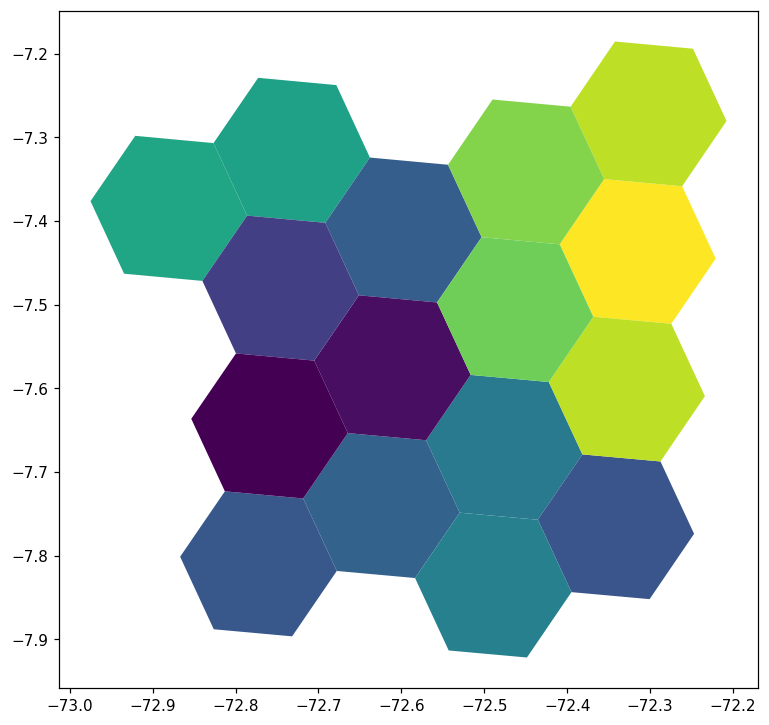

In [25]:
hexagons_with_data.plot(column='ndvi', legend=False, cmap='viridis', figsize=(10, 8))


In [26]:
export_hexagrid_results(hexagons_with_data, output_path=OUTPUT_HEXAGRID_PATH)

2025-12-17 13:45:32,333 - INFO - Created 16 records
2025-12-17 13:45:32,341 - INFO - Created 16 records



Result saved to output/hexagrid


___